# 주성분 분석(PCA: Principal Component Analysis)
- 다차원의 데이터를 소차원의 데이터로 환원시키는 기법 

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [1]:
import numpy as np

fruits = np.load("../Data/fruits.npy")
fruits.shape

(300, 100, 100)

In [2]:
# 2차원 배열로 변경하기
fruits_2d = fruits.reshape(-1, 100*100)
fruits_2d.shape

(300, 10000)

# PCA 모델 구성하기

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50) # 300개의 데이터중 구별이 확실한 주성분 50개 선택 (Feature들 중 특징을 포함하여 구성)
pca.fit(fruits_2d)

PCA(n_components=50)

In [4]:
# 축소된 차원 크기 확인하기
pca.components_.shape

(50, 10000)

In [5]:
import matplotlib.pyplot as plt

def draw_fruits(arr,ratio=1):
     n = len(arr) # n은 샘플 갯수
     # 한 줄에 10개씩 이미지 그리기, 샘플 갯수를 10으로 나누어 전체 행 갯수 계산
     rows = int(np.ceil(n/10)) # 올림처리
     # 행이 1개이면 열 갯수가 샘플갯수이고 그렇지 않으면 10개
     cols = n if rows < 2 else 10
     
     fig,axs = plt.subplots(rows,cols,figsize=(cols*ratio,rows*ratio),squeeze=False)

     for i in range(rows):
        for j in range(cols):
            if i *10 + j < n: # n개까지만 그린다
                axs[i,j].imshow(arr[i*10+j],cmap='gray_r')
            axs[i,j].axis('off')
     plt.show()

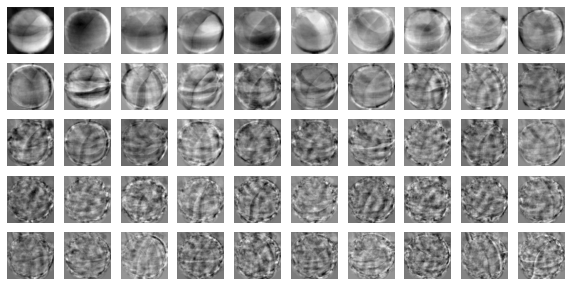

In [6]:
draw_fruits(pca.components_.reshape(-1, 100, 100))

In [7]:
# 행의 갯수는 원본과 동일하게 하고 Feature의 특성을 50개의 주성분으로 변경하기
print(fruits_2d.shape) # 원본 크기
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 10000)
(300, 50)


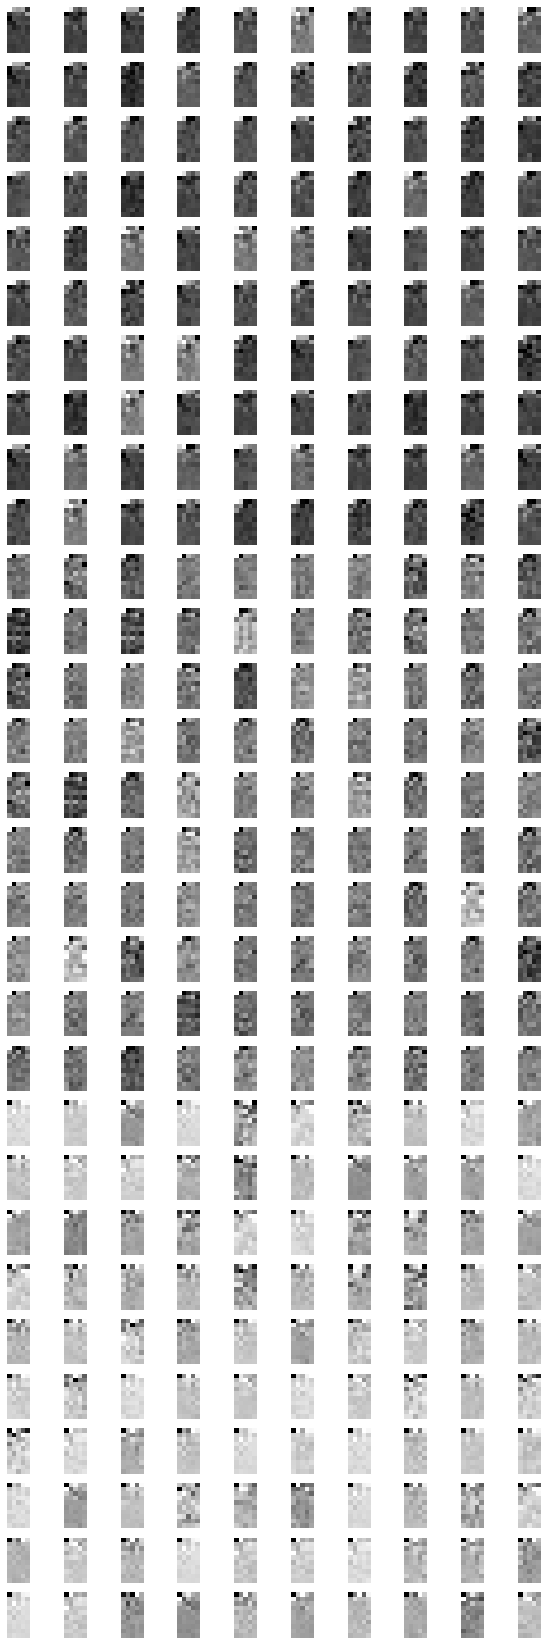

In [8]:
draw_fruits(fruits_pca.reshape(-1, 10, 5))
# 딥러닝에서는 CNN의 특징을 뽑아낸 것

---
## 원본 데이터 재구성

In [9]:
fruits_inverse = pca.inverse_transform(fruits_pca)
print(fruits_inverse.shape)

(300, 10000)


In [10]:
# 그림을 그리기 위해 2차원 확장
fruits_reconstruct = fruits_inverse.reshape(-1, 100, 100)
fruits_reconstruct.shape

(300, 100, 100)

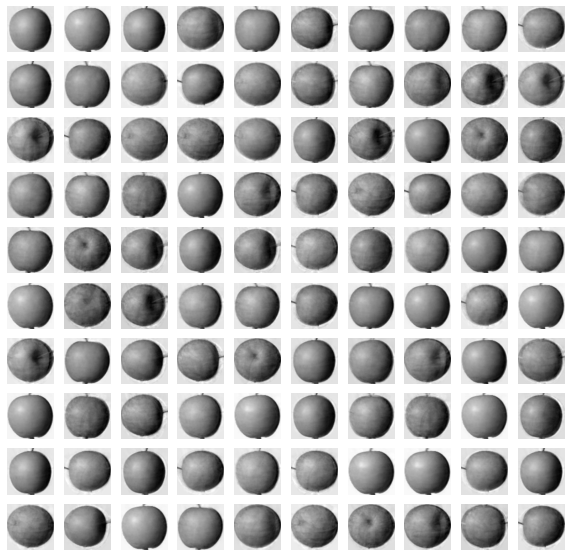

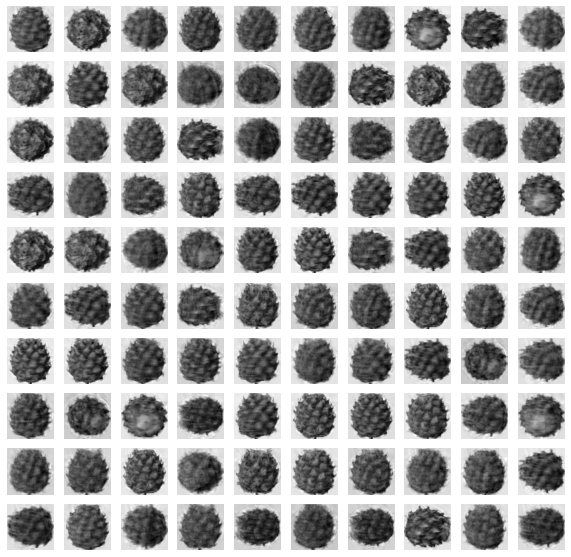

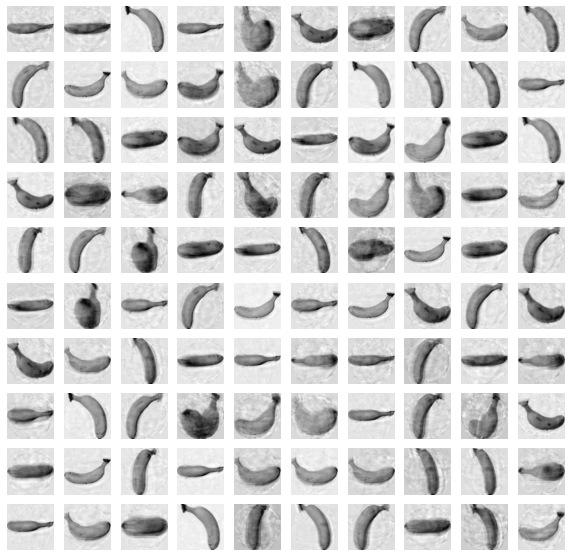

In [11]:

for start in [0, 100, 200]:
    draw_fruits(fruits_reconstruct[start:start+100])
    print("\n")

> 1/200의 데이터 특성만 가지고도 전반적으로 배경은 깨끗하지 않으나 물체의 구분은 가능하다.